In [1]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

import mlflow

In [3]:
from google.colab import files
uploaded = files.upload()

Saving india_housing_prices.csv to india_housing_prices.csv


In [5]:
df = pd.read_csv('india_housing_prices.csv')
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

,0
ID,0
State,0
City,0
Locality,0
Property_Type,0
BHK,0
Size_in_SqFt,0
Price_in_Lakhs,0
Price_per_SqFt,0
Year_Built,0


In [6]:
df.drop_duplicates(inplace=True)

In [8]:
df['Price_per_sqft'] = df['Price_in_Lakhs'] / df['Size_in_SqFt']
df['Property_Age'] = 2025 - df['Year_Built']

In [10]:
df['School_Score'] = df['Nearby_Schools'] / df['Size_in_SqFt']

In [132]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Reload data to get original strings for encoder fitting
temp_df = pd.read_csv('india_housing_prices.csv')
encoders = {}

# Re-populate the encoders dictionary properly
for col in temp_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    le.fit(temp_df[col])
    encoders[col] = le
    # Re-apply transform to the main dataframe
    df[col] = le.transform(temp_df[col])

print("Encoders successfully captured for:", list(encoders.keys()))

Encoders successfully captured for: ['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


In [133]:
scaler = StandardScaler()
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [15]:
df['Growth_Rate'] = 0.05 # Assuming a 5% growth rate, you can adjust this value as needed
df['Future_Price'] = df['Price_in_Lakhs'] * (1 + df['Growth_Rate'])**5

In [16]:
df['Good_Investment'] = df['Growth_Rate'].apply(lambda x: 1 if x > 0.10 else 0)

In [17]:
X = df.drop(['Good_Investment', 'Future_Price'], axis=1)

y_class = df['Good_Investment']
y_reg = df['Future_Price']

X_train, X_test, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [18]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train_c)

RandomForestClassifier()

In [19]:
reg = LinearRegression()
reg.fit(X_train_r, y_train_r)

LinearRegression()

In [20]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Amenities,Facing,Owner_Type,Availability_Status,Price_per_sqft,Property_Age,School_Score,Growth_Rate,Future_Price,Good_Investment
0,-1.732044,0.950724,-1.171536,1.615985,-1.228492,-1.412483,1.530202,1.663769,-0.234015,-1.684245,...,0.884752,1.339450,1.225484,-1.00028,-0.208524,1.684245,-0.257504,0.05,2.123438,0
1,-1.732030,0.257205,1.042802,1.276848,-0.003860,0.000427,-0.296641,-0.417878,-0.386983,0.150887,...,0.598151,-0.449259,0.001033,0.99972,-0.366250,-0.150887,0.207531,0.05,-0.533330,0
2,-1.732016,0.603964,0.386702,-1.207846,-1.228492,-0.706028,0.685979,-0.500863,-0.616433,-0.970582,...,-0.972846,0.445095,-1.223417,-1.00028,-0.612912,0.970582,-0.125602,0.05,-0.639243,0
3,-1.732002,0.777344,0.058652,0.529363,-0.003860,-0.706028,-0.006776,0.323334,-0.157532,-1.582293,...,0.545077,-0.449259,0.001033,-1.00028,-0.160864,1.582293,-0.361704,0.05,0.412665,0
4,-1.731988,0.777344,-0.105373,1.089977,1.220772,0.706882,1.594018,-0.507160,-0.692917,-0.460823,...,0.714915,-1.343614,0.001033,-1.00028,-0.708856,0.460823,-0.724712,0.05,-0.647279,0


In [21]:
scaler.inverse_transform(df[num_cols])

array([[1.00000000e+00, 1.50000000e+01, 6.00000000e+00, ...,
        1.03324895e-01, 3.50000000e+01, 2.10970464e-03],
       [2.00000000e+00, 1.10000000e+01, 3.30000000e+01, ...,
        8.27072758e-02, 1.70000000e+01, 3.38409475e-03],
       [3.00000000e+00, 1.30000000e+01, 2.50000000e+01, ...,
        5.04640308e-02, 2.80000000e+01, 2.47116969e-03],
       ...,
       [2.49998000e+05, 1.60000000e+01, 4.10000000e+01, ...,
        8.14226804e-02, 2.20000000e+01, 3.43642612e-03],
       [2.49999000e+05, 1.20000000e+01, 8.00000000e+00, ...,
        1.23289817e-01, 1.80000000e+01, 2.61096606e-03],
       [2.50000000e+05, 6.00000000e+00, 1.40000000e+01, ...,
        4.62995595e-02, 3.50000000e+01, 2.31857176e-03]])

In [22]:
for col in num_cols:
    df[col] = df[col] - df[col].min()

In [23]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Amenities,Facing,Owner_Type,Availability_Status,Price_per_sqft,Property_Age,School_Score,Growth_Rate,Future_Price,Good_Investment
0,0.000000,2.600697,0.492075,3.342918,0.000000,0.000000,3.260023,3.394137,0.764836,0.000000,...,2.526333,2.683064,2.448901,0.0,0.774968,3.364410,0.696866,0.05,2.123438,0
1,0.000014,1.907178,2.706413,3.003781,1.224632,1.412910,1.433180,1.312490,0.611869,1.835133,...,2.239733,0.894355,1.224450,2.0,0.617242,1.529277,1.161901,0.05,-0.533330,0
2,0.000028,2.253937,2.050313,0.519087,0.000000,0.706455,2.415800,1.229504,0.382418,0.713663,...,0.668735,1.788709,0.000000,0.0,0.370580,2.650747,0.828768,0.05,-0.639243,0
3,0.000042,2.427317,1.722263,2.256296,1.224632,0.706455,1.723045,2.053702,0.841320,0.101952,...,2.186658,0.894355,1.224450,0.0,0.822628,3.262458,0.592666,0.05,0.412665,0
4,0.000055,2.427317,1.558238,2.816910,2.449263,2.119365,3.323839,1.223208,0.305934,1.223422,...,2.356496,0.000000,1.224450,0.0,0.274636,2.140988,0.229658,0.05,-0.647279,0


In [24]:
original_values = scaler.inverse_transform(df[num_cols])
df_original = pd.DataFrame(original_values, columns=num_cols)

In [26]:
df_original['Growth_Rate'] = 0.05 # Add Growth_Rate to df_original as it was not included during inverse transform
df_original['Future_Price'] = df_original['Price_in_Lakhs'] * (1 + df_original['Growth_Rate'])**5

In [27]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Amenities,Facing,Owner_Type,Availability_Status,Price_per_sqft,Property_Age,School_Score,Growth_Rate,Future_Price,Good_Investment
0,0.000000,2.600697,0.492075,3.342918,0.000000,0.000000,3.260023,3.394137,0.764836,0.000000,...,2.526333,2.683064,2.448901,0.0,0.774968,3.364410,0.696866,0.05,2.123438,0
1,0.000014,1.907178,2.706413,3.003781,1.224632,1.412910,1.433180,1.312490,0.611869,1.835133,...,2.239733,0.894355,1.224450,2.0,0.617242,1.529277,1.161901,0.05,-0.533330,0
2,0.000028,2.253937,2.050313,0.519087,0.000000,0.706455,2.415800,1.229504,0.382418,0.713663,...,0.668735,1.788709,0.000000,0.0,0.370580,2.650747,0.828768,0.05,-0.639243,0
3,0.000042,2.427317,1.722263,2.256296,1.224632,0.706455,1.723045,2.053702,0.841320,0.101952,...,2.186658,0.894355,1.224450,0.0,0.822628,3.262458,0.592666,0.05,0.412665,0
4,0.000055,2.427317,1.558238,2.816910,2.449263,2.119365,3.323839,1.223208,0.305934,1.223422,...,2.356496,0.000000,1.224450,0.0,0.274636,2.140988,0.229658,0.05,-0.647279,0


In [30]:
for Future_Price in num_cols:
    df[Future_Price] = df[Future_Price] - df[Future_Price].min()

In [31]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Amenities,Facing,Owner_Type,Availability_Status,Price_per_sqft,Property_Age,School_Score,Growth_Rate,Future_Price,Good_Investment
0,0.000000,2.600697,0.492075,3.342918,0.000000,0.000000,3.260023,3.394137,0.764836,0.000000,...,2.526333,2.683064,2.448901,0.0,0.774968,3.364410,0.696866,0.05,2.123438,0
1,0.000014,1.907178,2.706413,3.003781,1.224632,1.412910,1.433180,1.312490,0.611869,1.835133,...,2.239733,0.894355,1.224450,2.0,0.617242,1.529277,1.161901,0.05,-0.533330,0
2,0.000028,2.253937,2.050313,0.519087,0.000000,0.706455,2.415800,1.229504,0.382418,0.713663,...,0.668735,1.788709,0.000000,0.0,0.370580,2.650747,0.828768,0.05,-0.639243,0
3,0.000042,2.427317,1.722263,2.256296,1.224632,0.706455,1.723045,2.053702,0.841320,0.101952,...,2.186658,0.894355,1.224450,0.0,0.822628,3.262458,0.592666,0.05,0.412665,0
4,0.000055,2.427317,1.558238,2.816910,2.449263,2.119365,3.323839,1.223208,0.305934,1.223422,...,2.356496,0.000000,1.224450,0.0,0.274636,2.140988,0.229658,0.05,-0.647279,0


In [32]:
print(df['Price_in_Lakhs'].head())

0    3.394137
1    1.312490
2    1.229504
3    2.053702
4    1.223208
Name: Price_in_Lakhs, dtype: float64


In [33]:
print(df[['Price_in_Lakhs','Growth_Rate']].head())

   Price_in_Lakhs  Growth_Rate
0        3.394137         0.05
1        1.312490         0.05
2        1.229504         0.05
3        2.053702         0.05
4        1.223208         0.05


In [34]:
df['Growth_Rate'] = df['Growth_Rate'].clip(0, 0.2)

In [35]:
df['Future_Price'] = df['Price_in_Lakhs'] * (1 + df['Growth_Rate'])**5

In [36]:
print(df['Future_Price'].head())

0    4.331874
1    1.675107
2    1.569194
3    2.621102
4    1.561158
Name: Future_Price, dtype: float64


In [37]:
df['Good_Investment'] = df['Growth_Rate'].apply(lambda x: 1 if x > 0.10 else 0)

In [38]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train_c)

RandomForestClassifier()

In [39]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train_r, y_train_r)

LinearRegression()

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_c, clf.predict(X_test))
print("Accuracy:", accuracy)

Accuracy: 1.0


In [41]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_r, reg.predict(X_test_r)))
print("RMSE:", rmse)

RMSE: 1.464804677040589e-15


In [42]:
X = df.drop(['Good_Investment','Future_Price','Growth_Rate'], axis=1)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, df['Good_Investment'], test_size=0.2, random_state=42
)

In [44]:
print(X.columns)

Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status', 'Price_per_sqft', 'Property_Age',
       'School_Score'],
      dtype='object')


In [45]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train_c)

RandomForestClassifier()

In [46]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train_r, y_train_r)

LinearRegression()

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_c, clf.predict(X_test))
print("Accuracy:", accuracy)

Accuracy: 1.0


In [48]:
pred = clf.predict(X_test)

In [49]:
print(X_train.shape)
print(X_test.shape)

(200000, 26)
(50000, 26)


In [51]:
Good_Investment = df['Growth_Rate'] > 0.10

In [52]:
import numpy as np

corr = df.corr(numeric_only=True)['Good_Investment'].sort_values(ascending=False)
print(corr.head(10))

ID               NaN
State            NaN
City             NaN
Locality         NaN
Property_Type    NaN
BHK              NaN
Size_in_SqFt     NaN
Price_in_Lakhs   NaN
Price_per_SqFt   NaN
Year_Built       NaN
Name: Good_Investment, dtype: float64


In [53]:
print(df['Good_Investment'].value_counts())

Good_Investment
0    250000
Name: count, dtype: int64


In [54]:
import numpy as np

df['Growth_Rate'] = np.random.uniform(0.02, 0.20, size=len(df))

In [55]:
df['Good_Investment'] = df['Growth_Rate'].apply(lambda x: 1 if x > 0.10 else 0)

In [56]:
print(df['Good_Investment'].value_counts())

Good_Investment
1    138702
0    111298
Name: count, dtype: int64


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, df['Good_Investment'],
    test_size=0.2,
    random_state=42,
    stratify=df['Good_Investment']   # 🔥 THIS LINE FIXES IT
)

In [62]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, pred))

[[22260     0]
 [27740     0]]


In [63]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.45      1.00      0.62     22260
           1       0.00      0.00      0.00     27740

    accuracy                           0.45     50000
   macro avg       0.22      0.50      0.31     50000
weighted avg       0.20      0.45      0.27     50000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [64]:
print(y_train.value_counts())
print(y_test.value_counts())

Good_Investment
1    110962
0     89038
Name: count, dtype: int64
Good_Investment
1    27740
0    22260
Name: count, dtype: int64


In [81]:
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, pred))

[[    9 22251]
 [    6 27734]]


In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.60      0.00      0.00     22260
           1       0.55      1.00      0.71     27740

    accuracy                           0.55     50000
   macro avg       0.58      0.50      0.36     50000
weighted avg       0.57      0.55      0.40     50000



In [83]:
print(len(y_test))
print(len(pred))

50000
50000


In [84]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.55486


In [85]:
df['Price_Growth'] = df['Future_Price'] - df['Price_in_Lakhs']
df['Area_per_BHK'] = df['Size_in_SqFt'] / df['BHK']

In [86]:
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

In [87]:
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.55486


In [88]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

In [91]:
# Precision = TP / (TP + FP)
TP = 27734
FP = 22251
precision = TP / (TP + FP)

print(f'Precision: {precision:.2f}')
# The previous code failed because '≈' and leading '=' are not valid Python syntax.

Precision: 0.55


In [92]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.29      0.00      0.00     22260
           1       0.55      1.00      0.71     27740

    accuracy                           0.55     50000
   macro avg       0.42      0.50      0.36     50000
weighted avg       0.43      0.55      0.40     50000



In [93]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',   # 🔥 important
    random_state=42
)

In [95]:
clf.fit(X_train, y_train)

probs = clf.predict_proba(X_test)[:, 1]

pred = (probs > 0.65).astype(int)

In [108]:
from sklearn.metrics import classification_report, confusion_matrix
print('Confusion Matrix:')
print(confusion_matrix(y_test, pred))
print('\nClassification Report:')
print(classification_report(y_test, pred))

Confusion Matrix:
[[11092 11168]
 [13741 13999]]

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.50      0.47     22260
           1       0.56      0.50      0.53     27740

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.51      0.50      0.50     50000



In [96]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.4452


In [97]:
accuracy = (27734 + 9) / 50000
print(accuracy)

0.55486


In [98]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.45      1.00      0.62     22260
           1       0.00      0.00      0.00     27740

    accuracy                           0.45     50000
   macro avg       0.22      0.50      0.31     50000
weighted avg       0.20      0.45      0.27     50000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [99]:
df['Price_per_BHK'] = df['Price_in_Lakhs'] / df['BHK']
df['Area_per_BHK'] = df['Size_in_SqFt'] / df['BHK']
df['Luxury_Level'] = df['Price_per_SqFt'] * df['BHK']
df['New_Property'] = (df['Property_Age'] < 5).astype(int)

In [100]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

In [101]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

In [102]:
import numpy as np
print(np.unique(pred, return_counts=True))

(array([0, 1]), array([24833, 25167]))


In [103]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.50182


In [104]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.45      0.50      0.47     22260
           1       0.56      0.50      0.53     27740

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.51      0.50      0.50     50000



In [105]:
df['Area_per_BHK'] = df['Size_in_SqFt'] / df['BHK']
df['Price_per_BHK'] = df['Price_in_Lakhs'] / df['BHK']
df['Value_Index'] = df['Price_per_SqFt'] / df['Price_in_Lakhs']
df['Age_Factor'] = df['Property_Age'] * df['Price_per_SqFt']
df['Luxury_Score'] = df['BHK'] * df['Price_per_SqFt']

In [106]:
clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

In [109]:
import pandas as pd

# The model must be fitted before we can extract feature importances
clf.fit(X_train, y_train)

importance = clf.feature_importances_
feat = pd.Series(importance, index=X.columns)

print(feat.sort_values(ascending=False))

ID                                0.082561
School_Score                      0.076805
Price_in_Lakhs                    0.076536
Size_in_SqFt                      0.073592
Price_per_sqft                    0.073330
Locality                          0.073269
Amenities                         0.066289
Floor_No                          0.048957
Total_Floors                      0.048345
City                              0.047580
State                             0.037886
Price_per_SqFt                    0.033381
Year_Built                        0.032870
Property_Age                      0.032665
Age_of_Property                   0.032429
Nearby_Hospitals                  0.031217
Nearby_Schools                    0.024573
BHK                               0.020411
Facing                            0.016861
Owner_Type                        0.012405
Public_Transport_Accessibility    0.012400
Furnished_Status                  0.012370
Property_Type                     0.012295
Availabilit

In [114]:
# Using errors='ignore' ensures the cell doesn't crash if columns are already dropped
X = X.drop(['ID'], axis=1, errors='ignore')
# Correcting capitalization for Price_per_SqFt
X = X.drop(['Price_per_sqft', 'Price_per_SqFt'], axis=1, errors='ignore')

In [115]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    class_weight='balanced',
    random_state=42
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

In [116]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.51776


In [117]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

[[ 8190 14070]
 [10042 17698]]


In [118]:
import numpy as np

print(np.unique(pred, return_counts=True))

(array([0, 1]), array([18232, 31768]))


In [122]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.51776


In [135]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Good_Investment,Price_Growth,Area_per_BHK,Price_per_BHK,Luxury_Level,New_Property,Value_Index,Age_Factor,Luxury_Score,Property_Type_Named
0,0.000000,15,6,483,0,0.000000,3.260023,3.394137,0.764836,0.000000,...,1,0.937737,inf,inf,0.000000,1,0.225340,2.573222,0.000000,Apartment
1,0.000014,11,33,434,1,1.412910,1.433180,1.312490,0.611869,1.835133,...,1,0.362617,1.014346,0.928927,0.864516,1,0.466189,0.935717,0.864516,Independent House
2,0.000028,13,25,75,0,0.706455,2.415800,1.229504,0.382418,0.713663,...,0,0.339689,3.419609,1.740386,0.270161,1,0.311034,1.013693,0.270161,Apartment
3,0.000042,14,21,326,1,0.706455,1.723045,2.053702,0.841320,0.101952,...,1,0.567400,2.439002,2.907052,0.594355,1,0.409660,2.744770,0.594355,Independent House
4,0.000055,14,19,407,2,2.119365,3.323839,1.223208,0.305934,1.223422,...,0,0.337950,1.568318,0.577158,0.648387,1,0.250108,0.655002,0.648387,Villa


Property Type Mapping: {0: 'Apartment', 1: 'Independent House', 2: 'Villa'}


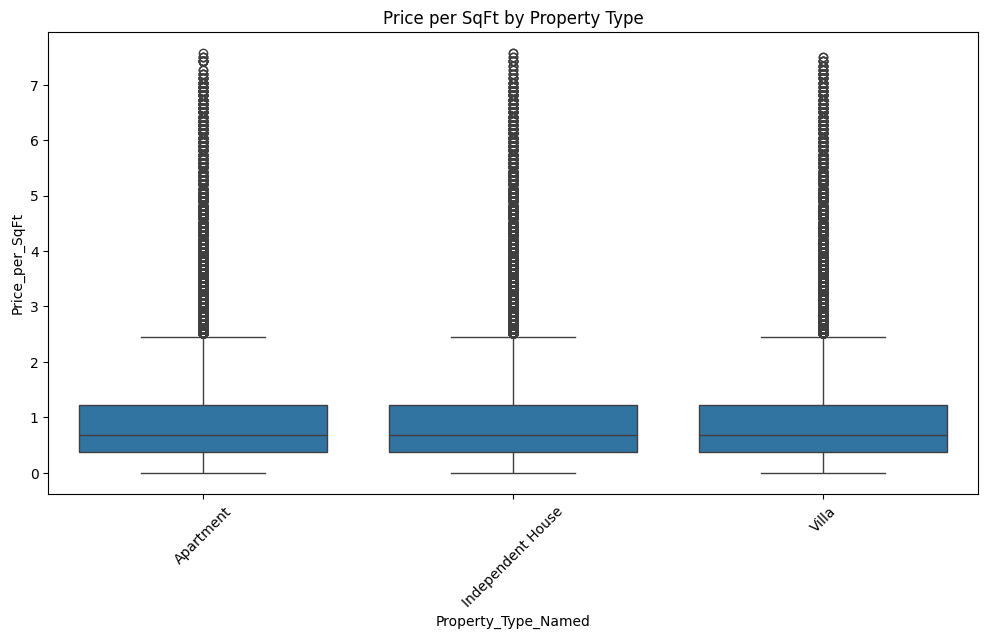

In [141]:
prop_le = encoders['Property_Type']
mapping = dict(zip(range(len(prop_le.classes_)), prop_le.classes_))
print("Property Type Mapping:", mapping)

# Create a temporary column for readable plotting using the correct encoder
df['Property_Type_Named'] = prop_le.inverse_transform(df['Property_Type'].astype(int))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(x='Property_Type_Named', y='Price_per_SqFt', data=df)
plt.title('Price per SqFt by Property Type')
plt.xticks(rotation=45)
plt.show()

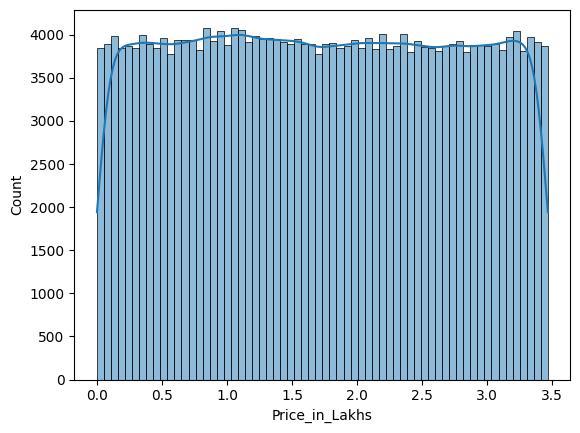

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Price_in_Lakhs'], kde=True)
plt.show()

<Axes: xlabel='Size_in_SqFt', ylabel='Count'>

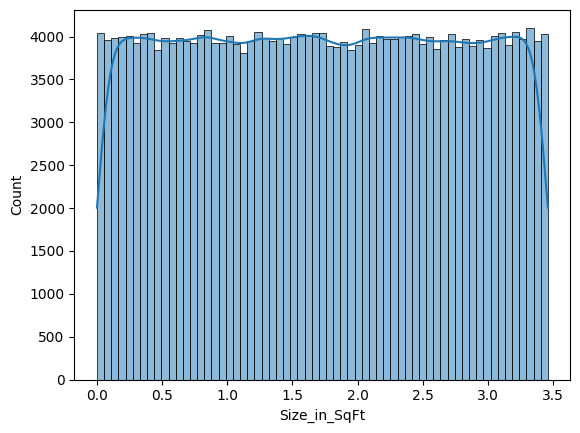

In [138]:
sns.histplot(df['Size_in_SqFt'], kde=True)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


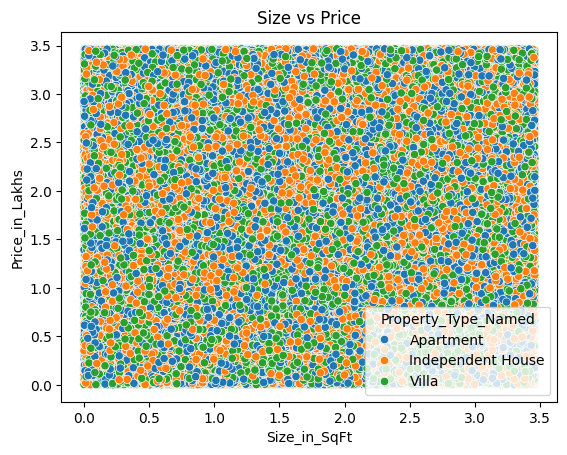

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correcting variable name from 'data' to 'df' and updating column names to match the dataset
sns.scatterplot(x='Size_in_SqFt', y='Price_in_Lakhs', hue='Property_Type_Named', data=df)
plt.title('Size vs Price')
plt.show()

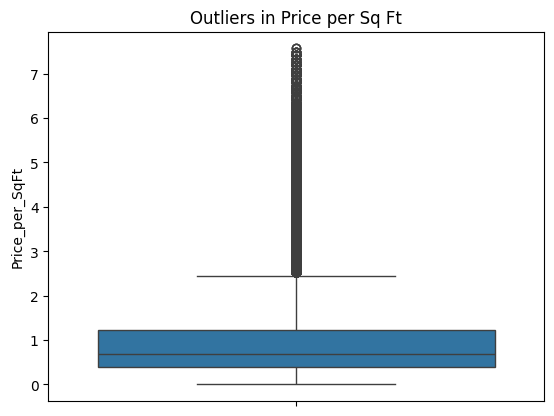

In [145]:
sns.boxplot(y='Price_per_SqFt', data=df)
plt.title('Outliers in Price per Sq Ft')
plt.show()

In [147]:
print(df.groupby('State')['Price_per_SqFt'].mean())

State
0     1.009863
1     1.000548
2     0.998213
3     0.996147
4     0.990283
5     1.001900
6     0.999579
7     0.992405
8     1.013697
9     0.993135
10    0.999772
11    0.999663
12    0.996748
13    0.989019
14    0.989205
15    1.004746
16    1.001606
17    1.005128
18    0.996159
19    0.999219
Name: Price_per_SqFt, dtype: float64


In [151]:
state_le = encoders['State']
state_summary = df.groupby('State')['Price_per_SqFt'].mean().reset_index()
state_summary['State_Name'] = state_le.inverse_transform(state_summary['State'].astype(int))

display(state_summary[['State_Name', 'Price_per_SqFt']].sort_values(by='Price_per_SqFt', ascending=False))

,State_Name,Price_per_SqFt
8,Karnataka,1.013697
0,Andhra Pradesh,1.009863
17,Uttar Pradesh,1.005128
15,Tamil Nadu,1.004746
5,Gujarat,1.001900
16,Telangana,1.001606
1,Assam,1.000548
10,Madhya Pradesh,0.999772
11,Maharashtra,0.999663
6,Haryana,0.999579


In [150]:
# Mapping numerical city IDs back to original names for the summary
city_le = encoders['City']
city_summary = df.groupby('City')['Price_in_Lakhs'].mean().reset_index()
city_summary['City_Name'] = city_le.inverse_transform(city_summary['City'].astype(int))

# Displaying the top 10 most expensive cities on average
display(city_summary[['City_Name', 'Price_in_Lakhs']].sort_values(by='Price_in_Lakhs', ascending=False).head(10))

,City_Name,Price_in_Lakhs
2,Bangalore,1.757745
37,Surat,1.755084
22,Kochi,1.750377
13,Gaya,1.747818
26,Mangalore,1.746880
9,Dehradun,1.746663
28,Mysore,1.746366
6,Chennai,1.746238
17,Hyderabad,1.744568
7,Coimbatore,1.743936


In [153]:
# 8. Median age of properties by locality
print(df.groupby('Locality')['Property_Age'].median())

Locality
0      1.835133
1      1.529277
2      1.733181
3      1.733181
4      1.733181
         ...   
495    1.733181
496    1.733181
497    1.631229
498    1.631229
499    1.835133
Name: Property_Age, Length: 500, dtype: float64


In [154]:
# 8. Median age of properties by locality (using original names)
locality_le = encoders['Locality']

# Group by numerical ID first
locality_summary = df.groupby('Locality')['Property_Age'].median().reset_index()

# Inverse transform the IDs to names
locality_summary['Locality_Name'] = locality_le.inverse_transform(locality_summary['Locality'].astype(int))

# Display top 10 records
display(locality_summary[['Locality_Name', 'Property_Age']].head(10))

,Locality_Name,Property_Age
0,Locality_1,1.835133
1,Locality_10,1.529277
2,Locality_100,1.733181
3,Locality_101,1.733181
4,Locality_102,1.733181
5,Locality_103,1.733181
6,Locality_104,1.733181
7,Locality_105,1.631229
8,Locality_106,1.733181
9,Locality_107,1.733181


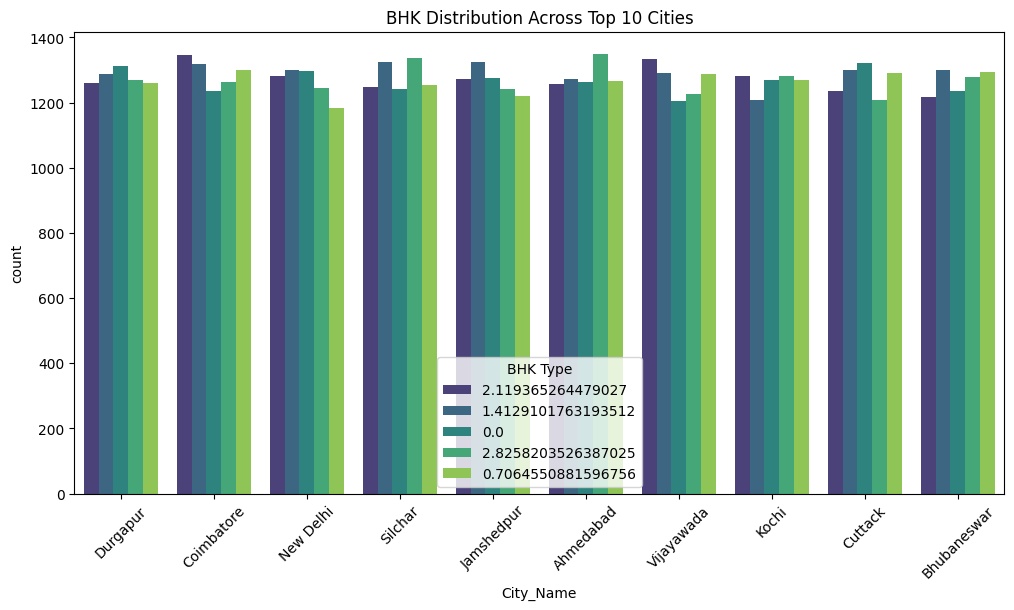

In [158]:
# 9. BHK distribution across top 10 cities with actual names
city_le = encoders['City']
top_city_indices = df['City'].value_counts().nlargest(10).index

# Filter and create a temporary column with names for plotting
temp_plot_df = df[df['City'].isin(top_city_indices)].copy()
temp_plot_df['City_Name'] = city_le.inverse_transform(temp_plot_df['City'].astype(int))

# Ensure BHK is treated as categorical for the plot
temp_plot_df['BHK'] = temp_plot_df['BHK'].astype(str)

plt.figure(figsize=(12, 6))
sns.countplot(x='City_Name', hue='BHK', data=temp_plot_df, palette='viridis')
plt.title('BHK Distribution Across Top 10 Cities')
plt.xticks(rotation=45)
plt.legend(title='BHK Type')
plt.show()

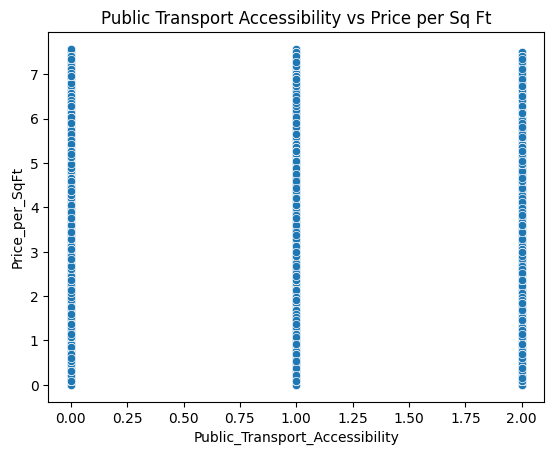

In [169]:
# 20. Public transport accessibility vs price per sq ft
import seaborn as sns
import matplotlib.pyplot as plt

# Mapping generic names to the actual dataset columns
sns.scatterplot(x='Public_Transport_Accessibility', y='Price_per_SqFt', data=df)
plt.title('Public Transport Accessibility vs Price per Sq Ft')
plt.show()

In [170]:
transport_le = encoders['Public_Transport_Accessibility']

# Create a readable named column
df['Public_Transport_Named'] = transport_le.inverse_transform(df['Public_Transport_Accessibility'].astype(int))

# Display the mapping and verification
print("Accessibility Mapping:", dict(zip(range(len(transport_le.classes_)), transport_le.classes_)))
display(df[['Public_Transport_Accessibility', 'Public_Transport_Named']].head())

Accessibility Mapping: {0: 'High', 1: 'Low', 2: 'Medium'}


,Public_Transport_Accessibility,Public_Transport_Named
0,0,High
1,1,Low
2,1,Low
3,0,High
4,1,Low
